# LaB₆ powder XRD: Le Bail fitting and Rietveld refinement

This notebook loads the LaB₆ diffraction pattern, uses a measured air pattern as its baseline, and refines the LaB₆ structure with **easyXRD** and **GSAS-II**. It follows the [easyXRD example notebooks](https://github.com/MehmetTopsakal/easyXRD_examples).

The analysis uses a wavelength of **0.1799 Å**, read from `_calibration.poni` (`1.799 × 10⁻¹¹ m`), and a selected range of **q = 1–10 Å⁻¹**. Instrument parameters start from `_instrument_parameters.gpx` and are subsequently refined against this pattern.

Run the cells in order using the Python environment at `/home/mt/mpixi`. Later cells use the `sample` and `bkg` objects created earlier. The final export cell saves the current refined project as `LaB6_refined.gpx`.

## 1. Libraries and plotting

Import easyXRD and the scientific Python libraries, enable inline plots, and display the interpreter and working directory. Run with this notebook's folder as the working directory so that the relative data paths resolve.

In [1]:
# Environment configuration and library imports
import os
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import fabio

# Import easyXRD core module
from easyxrd.core import exrd

# Configure plotting parameters
%matplotlib inline
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.constrained_layout.use"] = True

print(f"Python interpreter : {sys.executable}")
print(f"Working directory  : {Path.cwd()}")
print("easyXRD imported successfully.")


Python interpreter : /home/mt/mpixi/.pixi/envs/default/bin/python
Working directory  : /home/mt/temp/GPT-6-Astra-High
easyXRD imported successfully.


## 2. Load the LaB₆ diffraction pattern

Create the `sample` object and load `20260731-124851_A3E69F_count_LaB6_moving.xy`. Supply the wavelength in ångströms and restrict the analysis to `radial_range=[1, 10]`, expressed in q (Å⁻¹). Inspect the plotted pattern before proceeding.

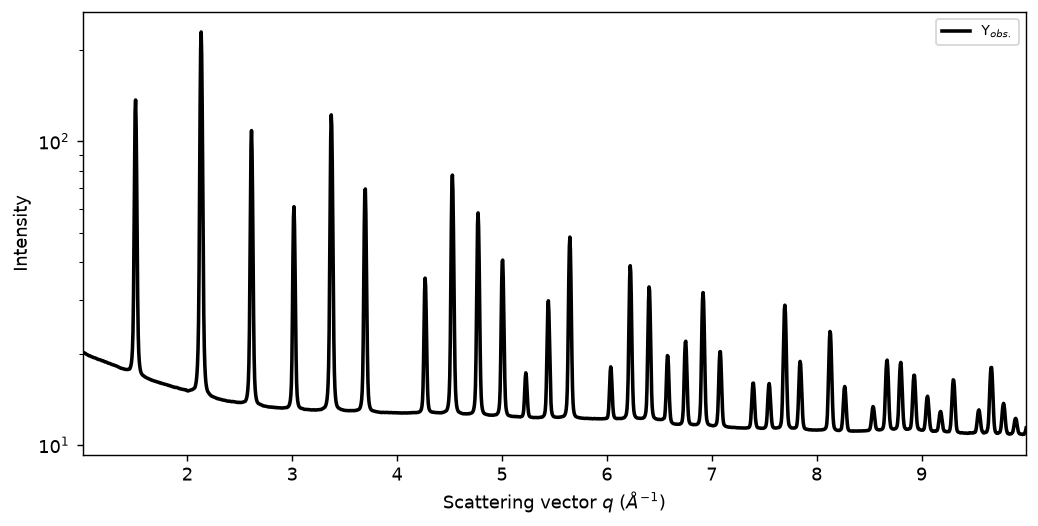

In [2]:
# Load the LaB6 1D XRD pattern.
# _calibration.poni gives wavelength = 1.799e-11 m = 0.1799 Å.
sample = exrd()
sample.load_xrd_data(
    from_txt_file="20260731-124851_A3E69F_count_LaB6_moving.xy",
    txt_file_wavelength_in_angstrom=0.1799,
    radial_range=[1, 10],  # q in Å⁻¹
    plot=True,
)


## 3. Load the crystal structure

Retrieve LaB₆ from Materials Project entry [mp-2680](https://next-gen.materialsproject.org/materials/mp-2680). The API key is read from `/home/mt/.easyxrd_scratch/mp_api_key.dat` at runtime.

The calculated reflections provide a first check of the phase assignment. The starting lattice parameters may differ from the measured sample; they will be refined below.

Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

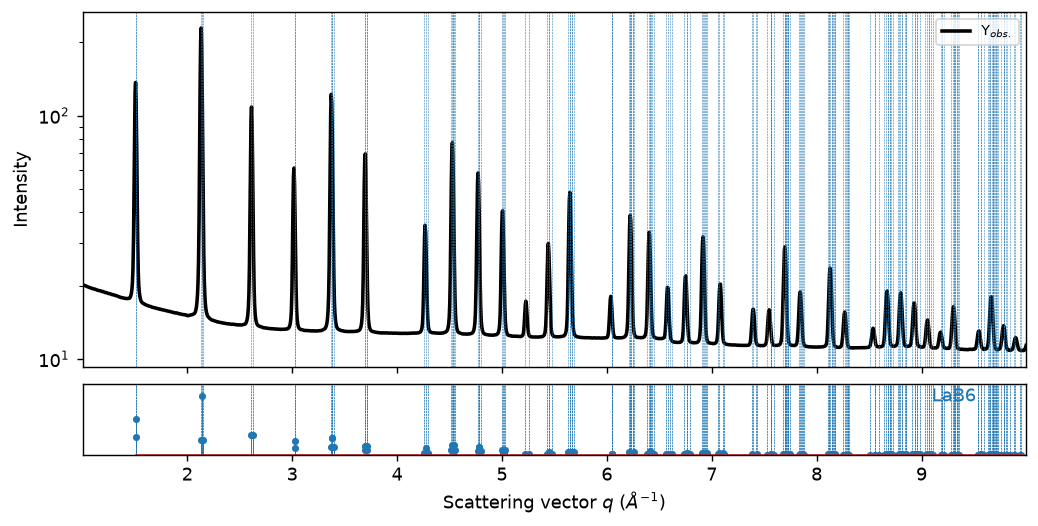

In [3]:
# Load the LaB6 crystal structure from Materials Project.
# https://next-gen.materialsproject.org/materials/mp-2680
phases = [
    {"mp_id": "mp-2680", "label": "LaB6"},
]

sample.load_phases(
    phases,
    mp_rester_api_key=Path("/home/mt/.easyxrd_scratch/mp_api_key.dat").read_text().strip(),
    plot=True,
)


## 4. Load the measured air background

Create a separate `bkg` object from `20260731-111250_935BAC_count_Air.xy`, using the same wavelength and q range as `sample`. This object supplies the experimental background; no crystal phases are loaded into it.

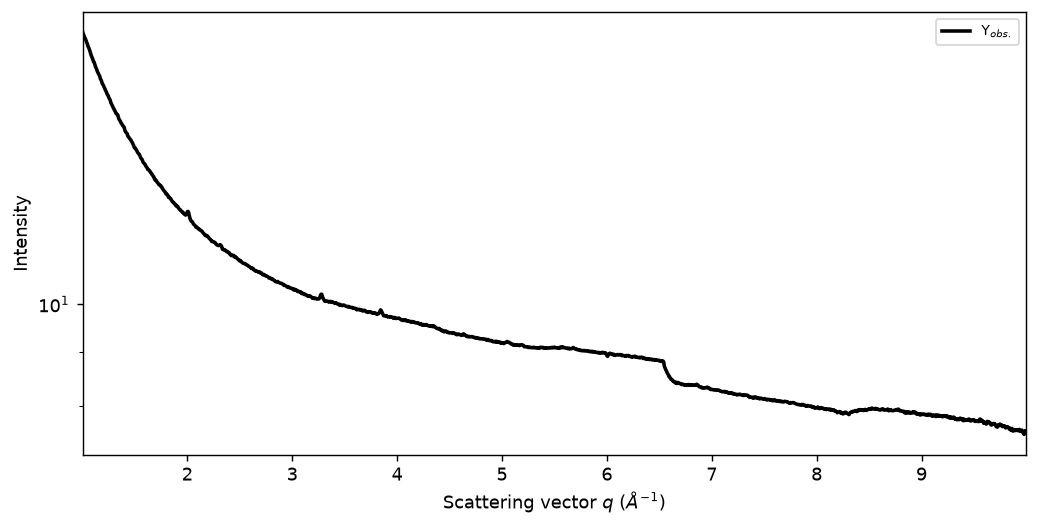

In [4]:
# Load the measured air background (wavelength from _calibration.poni).
bkg = exrd()
bkg.load_xrd_data(
    from_txt_file="20260731-111250_935BAC_count_Air.xy",
    txt_file_wavelength_in_angstrom=0.1799,
    radial_range=[1, 10],  # q in Å⁻¹
    plot=True,
)


### Use the air pattern as the baseline

Pass `bkg` to `sample.get_baseline`. Setting `use_iarpls=False` disables the IARPLS baseline estimator, so the baseline uses the supplied experimental background. Inspect the baseline and corrected pattern before refinement.

The later GSAS-II background refinement models residual background remaining after this baseline treatment.

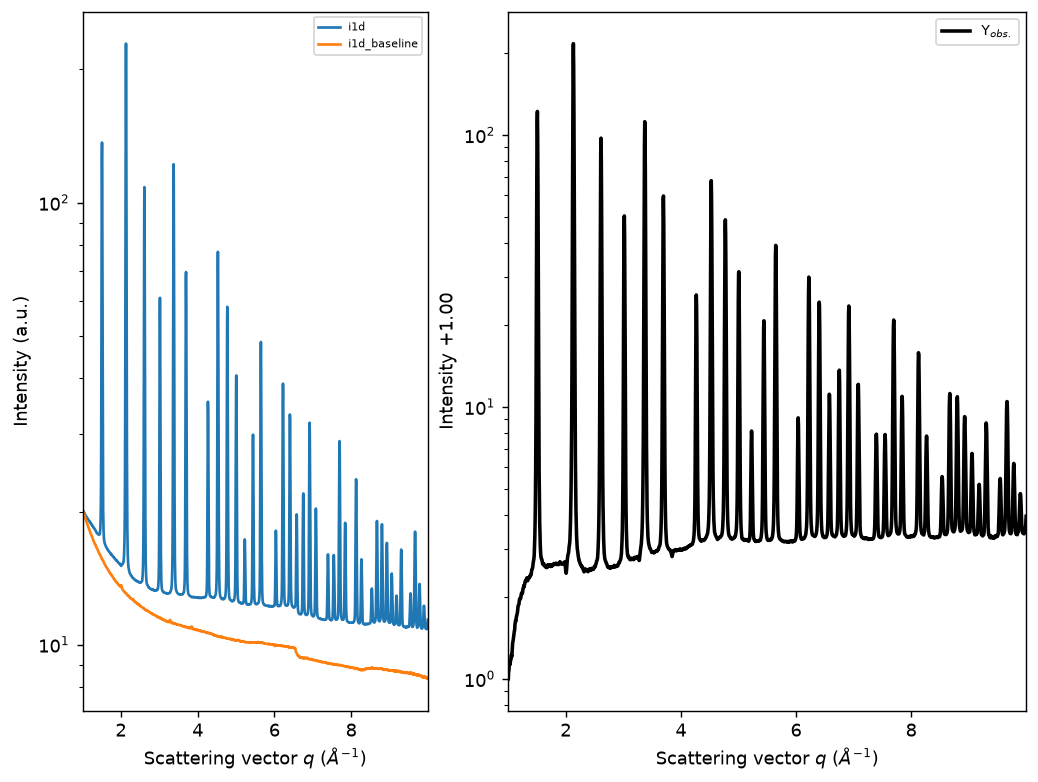

In [5]:
# Use the measured air background as the sample baseline, without IARPLS.
sample.get_baseline(input_bkg=bkg, use_iarpls=False)


## 5. Initialize the GSAS-II refiner

Initialize the refiner with instrument parameters from `_instrument_parameters.gpx` and plot the starting fit. At this stage, easyXRD uses **Le Bail fitting**, which adjusts reflection intensities without requiring them to match the atomic structure factors. The explicit switch to structural Rietveld refinement comes later.


 ⏩--1st refinement with LeBail is completed. Rwp/GoF is 70.605/1.607 



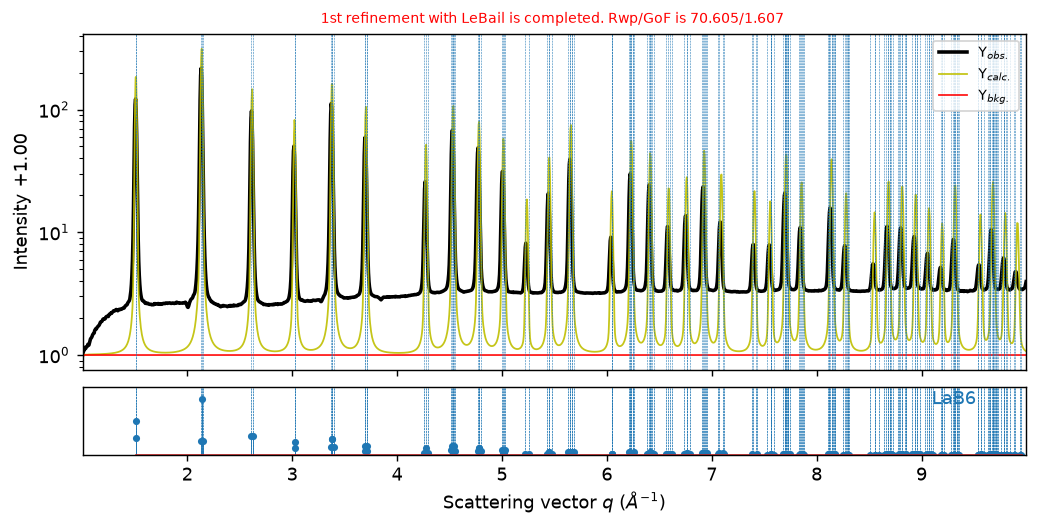

In [6]:
# Initialize the GSAS-II refiner using the saved instrument parameters.
sample.setup_gsas2_refiner(
    instprm_from_gpx="_instrument_parameters.gpx",
    plot=True,
)


## 6. Refine background and lattice parameters

First refine the residual background using easyXRD's default background settings. Inspect the difference curve as well as the reported fit statistics.

 ✅--Background with 10 coeffs is refined. Rwp/GoF is now 46.762/1.067 (was 70.605(-33.77%)/1.607(-33.58%✨))


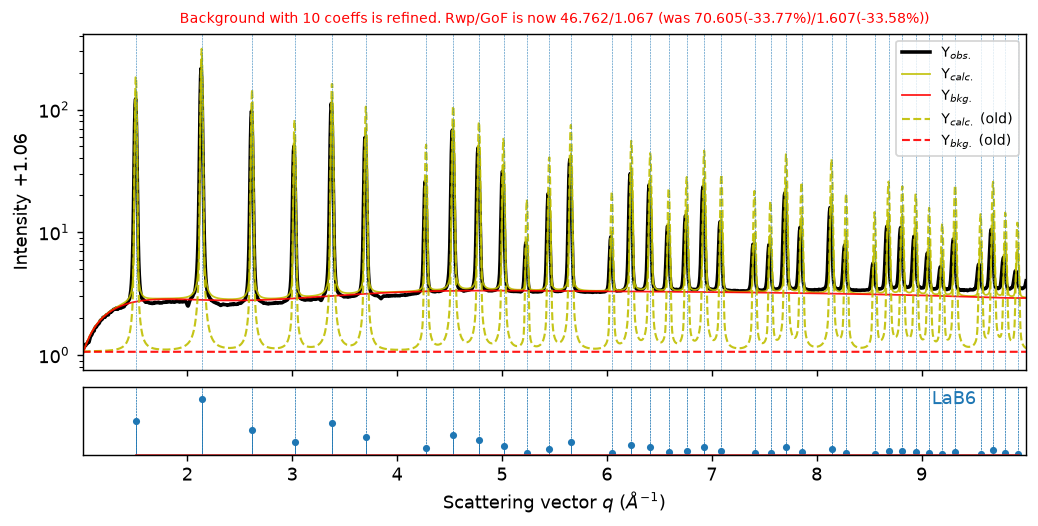

In [7]:
# Refine the background and display the fit.
sample.refine_background(plot=True)


### Refine the unit cell

Adjust the LaB₆ lattice parameters to improve agreement between observed and calculated peak positions. This step is followed by instrument-profile refinement.

 ✅--Cell parameters are refined. Rwp/GoF is now 16.461/0.375 (was 46.762(-64.80%)/1.067(-64.89%✨))


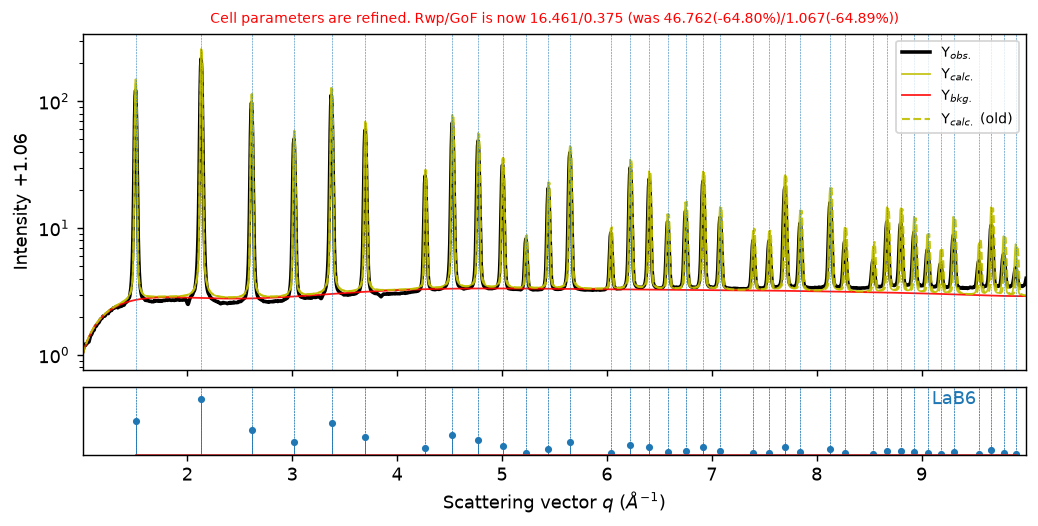

In [8]:
# Refine the unit cell parameters and display the fit.
sample.refine_cell_parameters(plot=True)


## 7. Refine instrument parameters sequentially

Refine one requested instrument parameter per call, in the order **U → V → W → X → Y → Z → SH/L → Zero**. Plot each intermediate fit to follow the changes.

| Parameters | Role in the profile model |
| --- | --- |
| U, V, W | Gaussian peak-width terms |
| X, Y, Z | Lorentzian peak-width terms |
| SH/L | Axial-divergence peak asymmetry |
| Zero | Angular zero offset |

These calls update the instrument parameters initially imported from the GPX file. Judge the fitted peak positions and shapes alongside the residual statistics.

 ✅--Instrument parameter ['U'] is refined. Rwp/GoF is now 11.547/0.263 (was 16.461(-29.85%)/0.375(-29.85%✨))


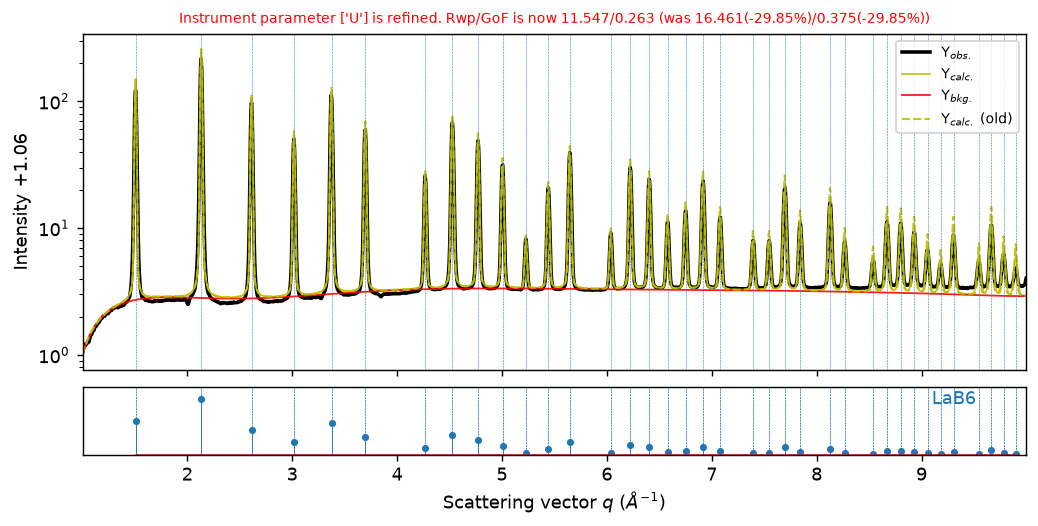

In [9]:
# Refine the U instrument parameter and display the fit.
sample.refine_instrument_parameters(inst_pars_to_refine=["U"], plot=True)


 ✅--Instrument parameter ['V'] is refined. Rwp/GoF is now 11.008/0.251 (was 11.547(-4.67%)/0.263(-4.67%))


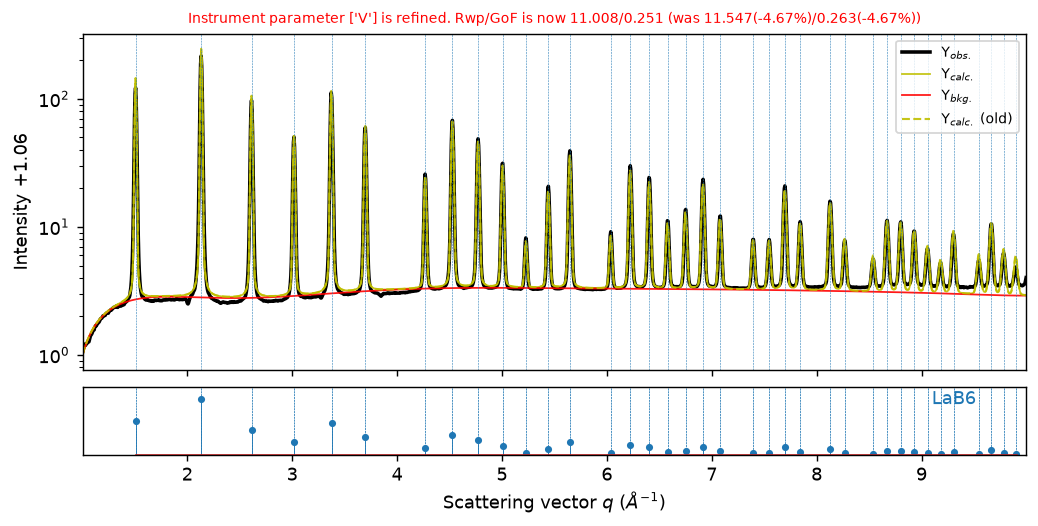

In [10]:
# Refine the V instrument parameter and display the fit.
sample.refine_instrument_parameters(inst_pars_to_refine=["V"], plot=True)


 ✅--Instrument parameter ['W'] is refined. Rwp/GoF is now 10.485/0.239 (was 11.008(-4.75%)/0.251(-4.75%))


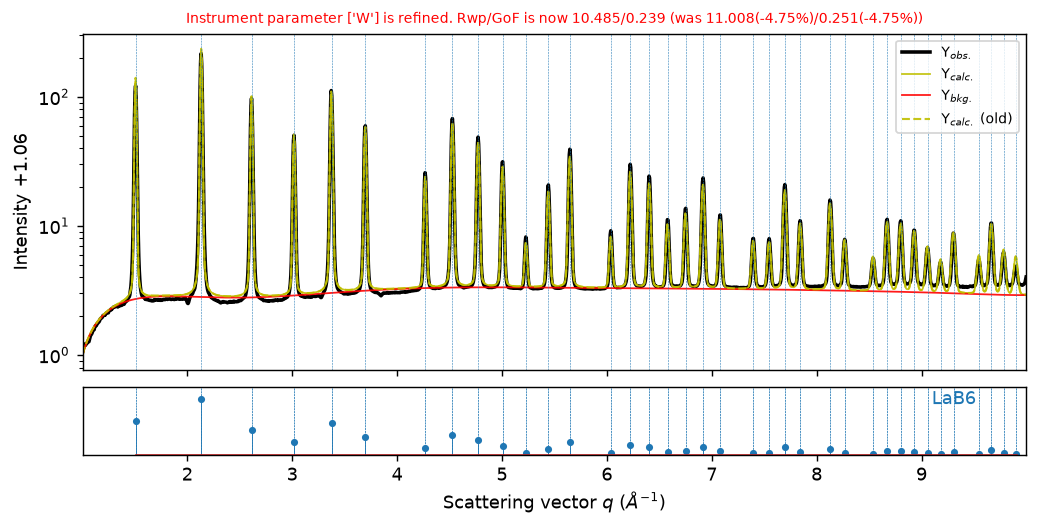

In [11]:
# Refine the W instrument parameter and display the fit.
sample.refine_instrument_parameters(inst_pars_to_refine=["W"], plot=True)


 ✅--Instrument parameter ['X'] is refined. Rwp/GoF is now 10.488/0.239 (was 10.485(0.03%)/0.239(0.03%❗))


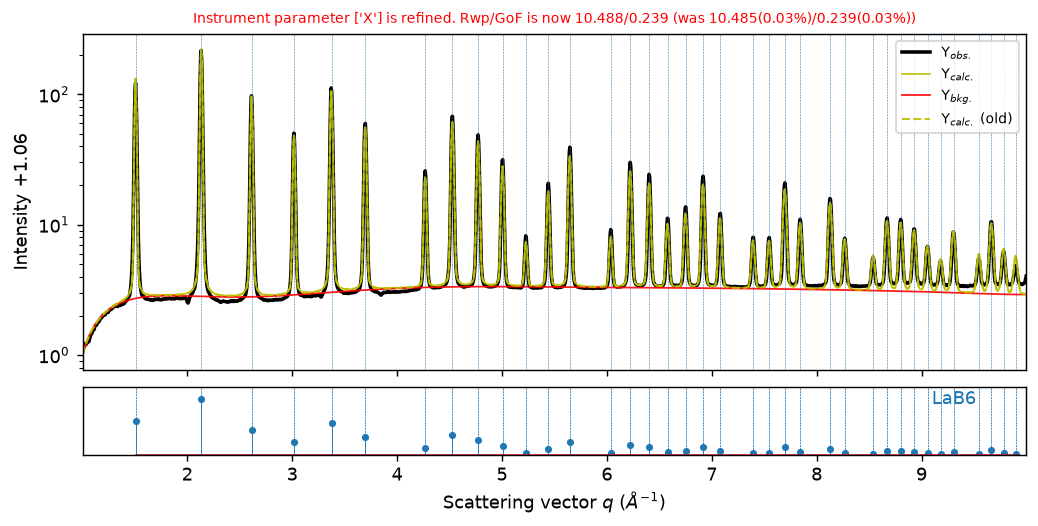

In [12]:
# Refine the X instrument parameter and display the fit.
sample.refine_instrument_parameters(inst_pars_to_refine=["X"], plot=True)


 ✅--Instrument parameter ['Y'] is refined. Rwp/GoF is now 10.194/0.232 (was 10.488(-2.80%)/0.239(-2.80%))


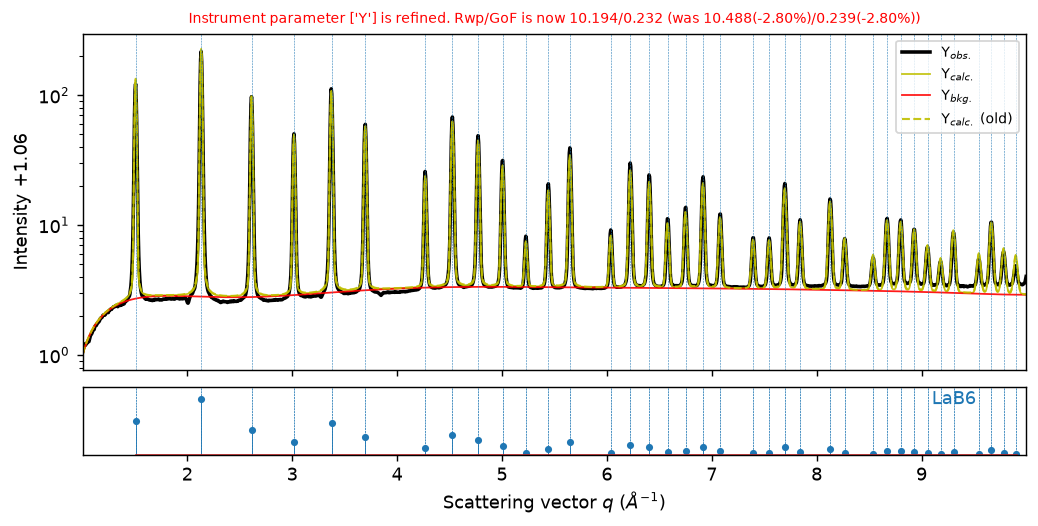

In [13]:
# Refine the Y instrument parameter and display the fit.
sample.refine_instrument_parameters(inst_pars_to_refine=["Y"], plot=True)


 ✅--Instrument parameter ['Z'] is refined. Rwp/GoF is now 10.000/0.228 (was 10.194(-1.90%)/0.232(-1.90%))


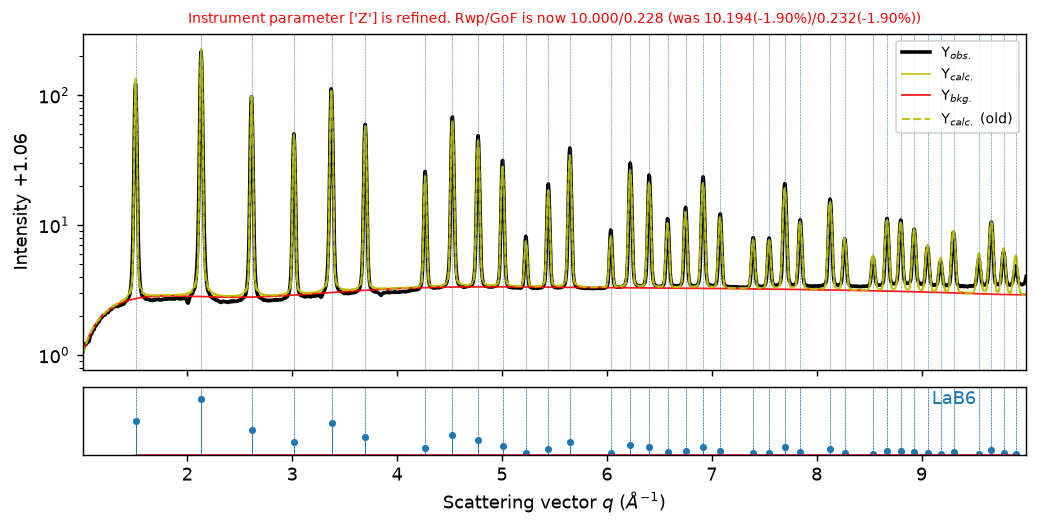

In [14]:
# Refine the Z instrument parameter and display the fit.
sample.refine_instrument_parameters(inst_pars_to_refine=["Z"], plot=True)


 ✅--Instrument parameter ['SH/L'] is refined. Rwp/GoF is now 9.670/0.220 (was 10.000(-3.30%)/0.228(-3.30%))


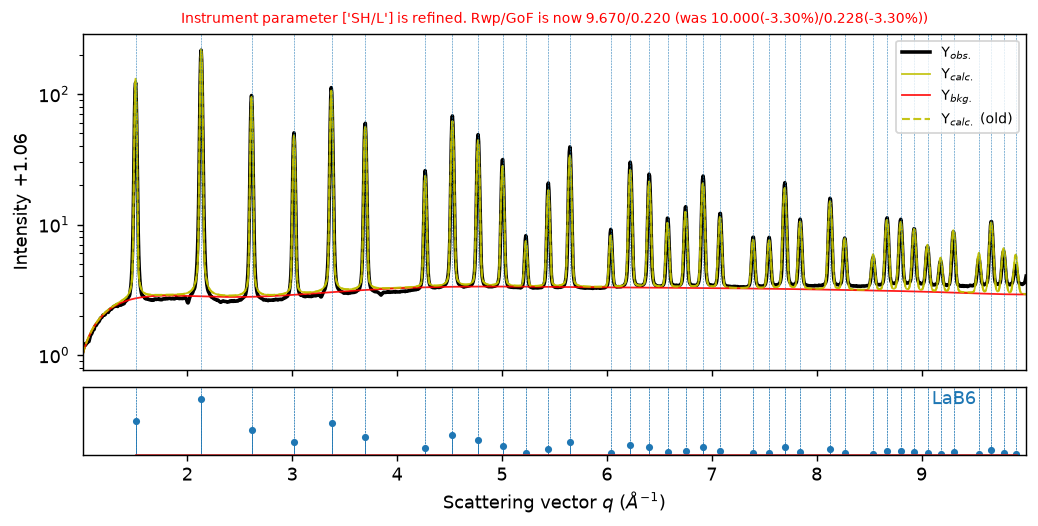

In [15]:
# Refine the SH/L instrument parameter and display the fit.
sample.refine_instrument_parameters(inst_pars_to_refine=["SH/L"], plot=True)


 ✅--Instrument parameter ['Zero'] is refined. Rwp/GoF is now 9.641/0.219 (was 9.670(-0.30%)/0.220(-0.30%❗))


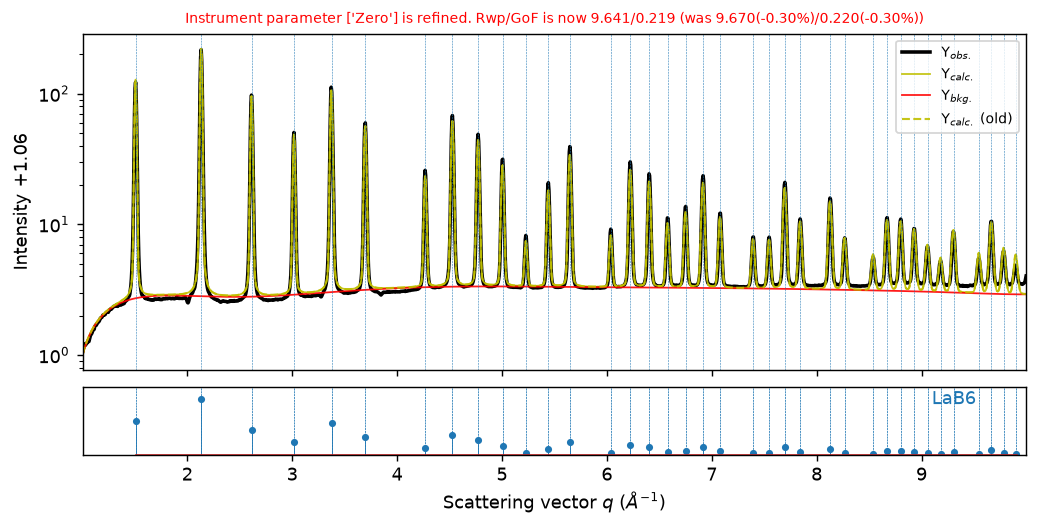

In [16]:
# Refine the Zero instrument parameter and display the fit.
sample.refine_instrument_parameters(inst_pars_to_refine=["Zero"], plot=True)


### Repeat the instrument-parameter sequence

Repeat the same eight refinements in the same order, retaining a plot after each call. This gives the parameters another pass after the first sequence has changed the profile model.

 ✅--Instrument parameter ['U'] is refined. Rwp/GoF is now 8.602/0.196 (was 9.641(-10.78%)/0.219(-10.78%✨))
 ✅--Instrument parameter ['V'] is refined. Rwp/GoF is now 8.563/0.195 (was 8.602(-0.45%)/0.196(-0.45%❗))
 ✅--Instrument parameter ['W'] is refined. Rwp/GoF is now 8.447/0.192 (was 8.563(-1.36%)/0.195(-1.36%))
 ✅--Instrument parameter ['X'] is refined. Rwp/GoF is now 8.441/0.192 (was 8.447(-0.07%)/0.192(-0.07%❗))
 ✅--Instrument parameter ['Y'] is refined. Rwp/GoF is now 8.384/0.191 (was 8.441(-0.67%)/0.192(-0.67%❗))
 ✅--Instrument parameter ['Z'] is refined. Rwp/GoF is now 8.376/0.191 (was 8.384(-0.10%)/0.191(-0.10%❗))
 ✅--Instrument parameter ['SH/L'] is refined. Rwp/GoF is now 8.343/0.190 (was 8.376(-0.40%)/0.191(-0.40%❗))
 ✅--Instrument parameter ['Zero'] is refined. Rwp/GoF is now 8.330/0.190 (was 8.343(-0.16%)/0.190(-0.16%❗))


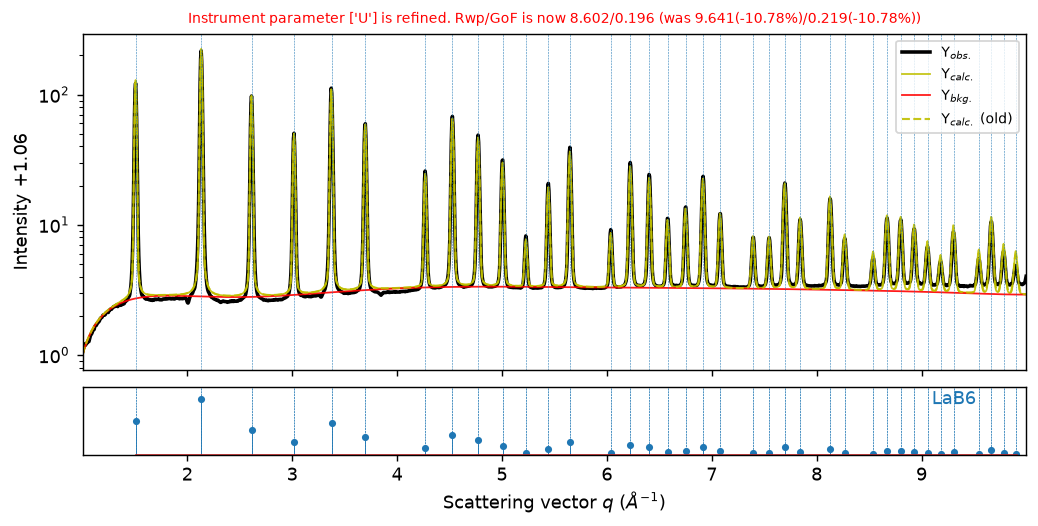

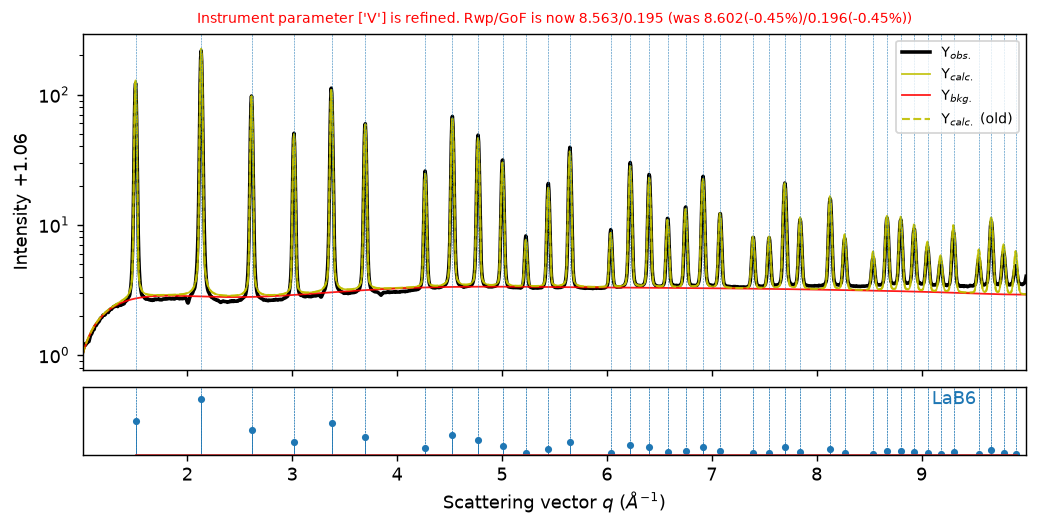

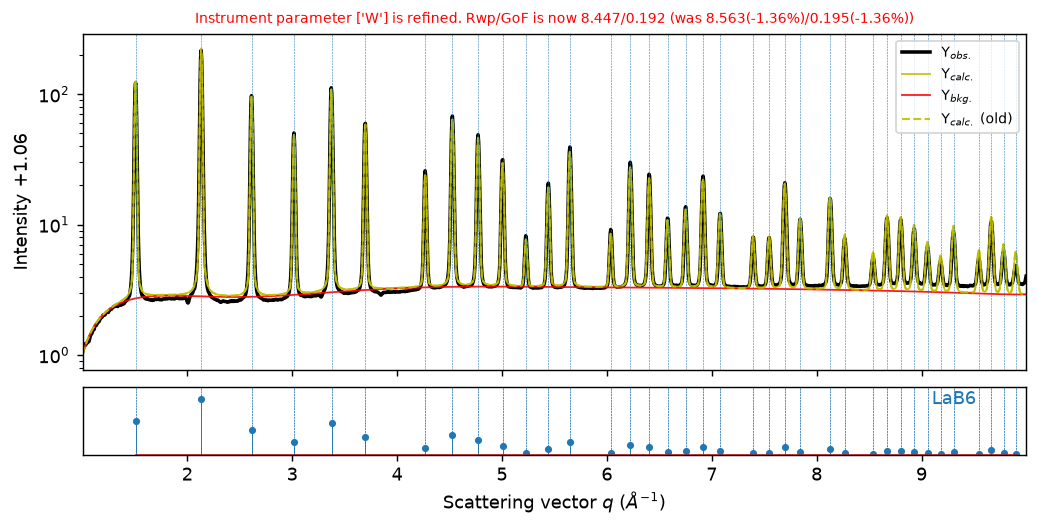

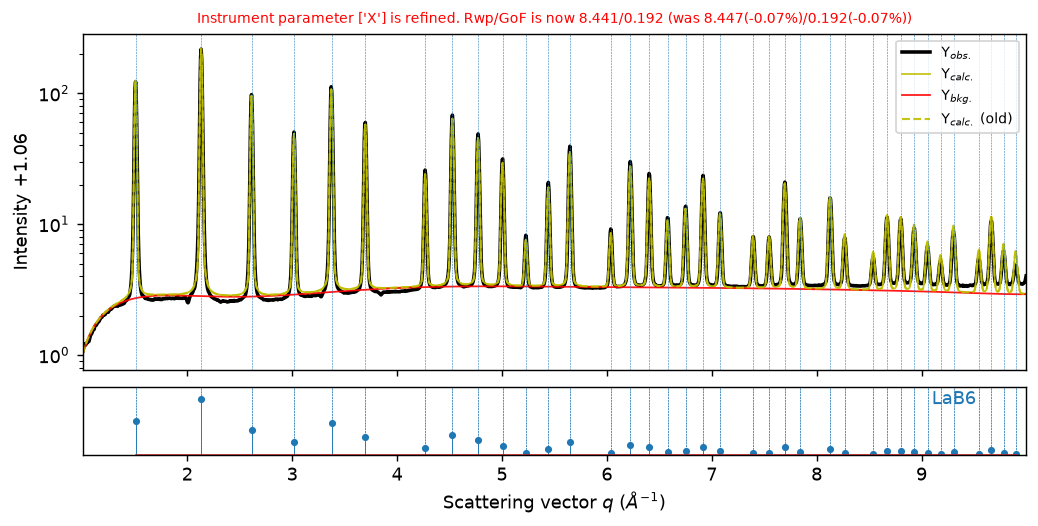

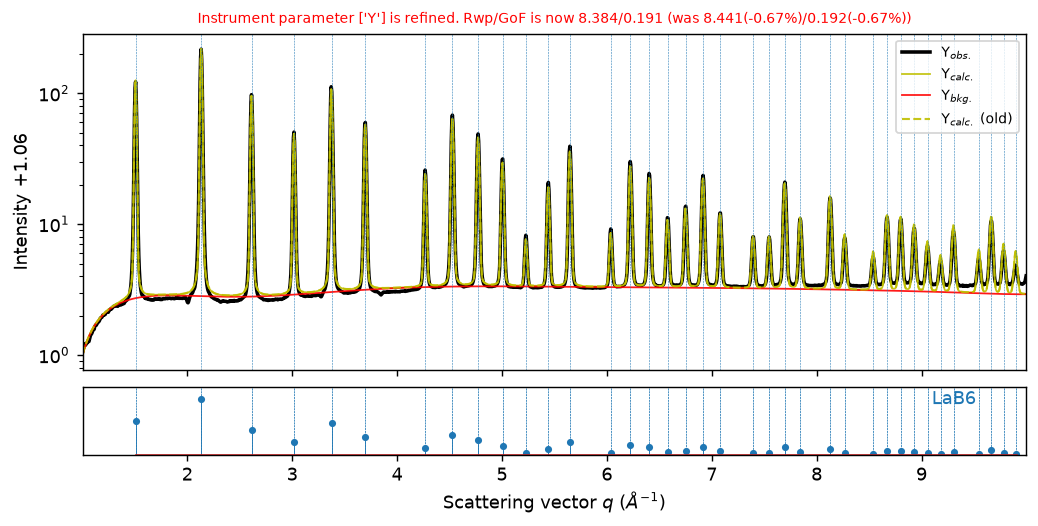

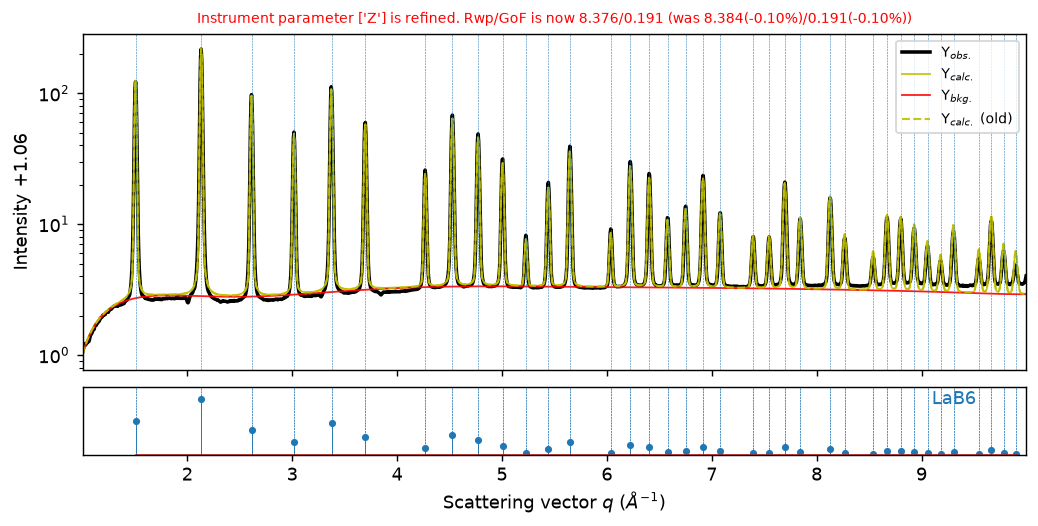

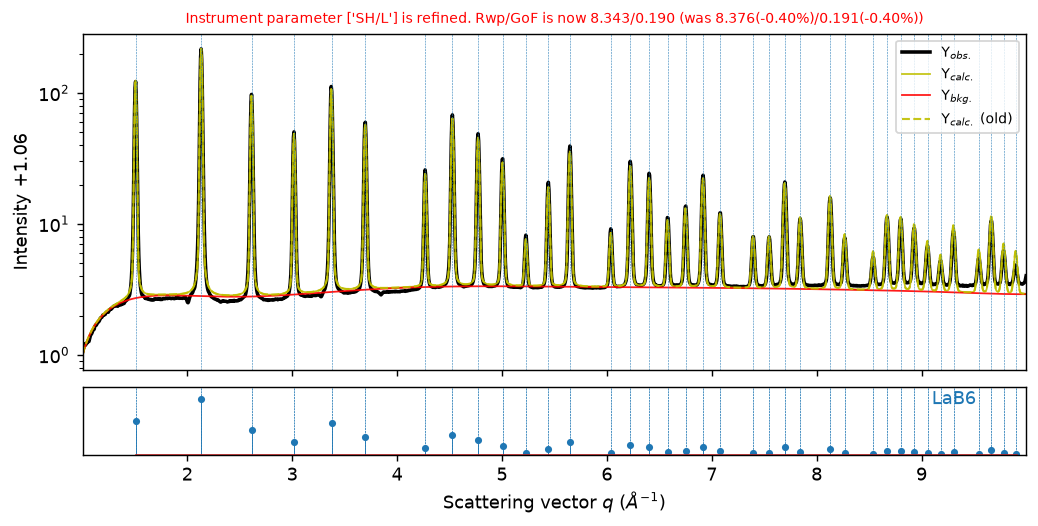

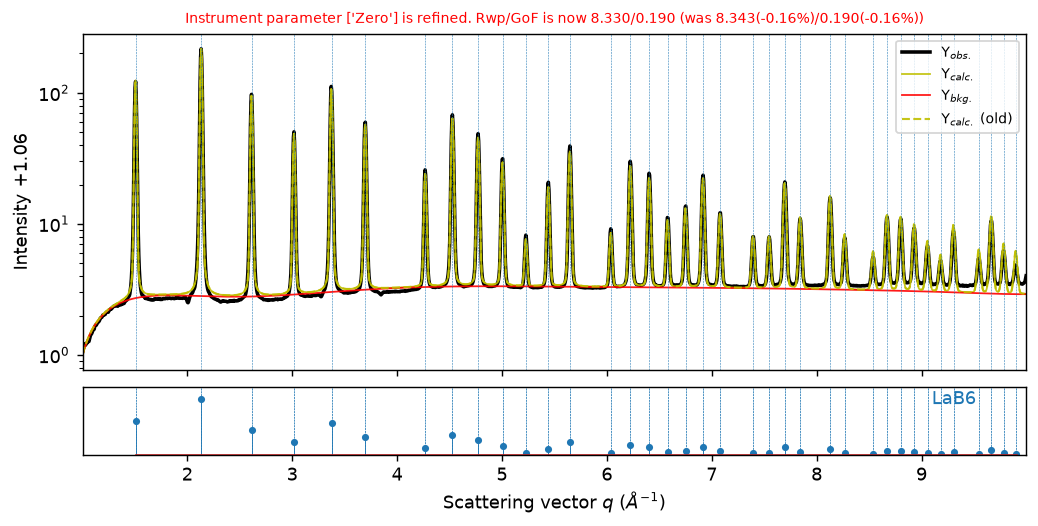

In [17]:
# Refine the U instrument parameter and display the fit.
sample.refine_instrument_parameters(inst_pars_to_refine=["U"], plot=True)

# Refine the V instrument parameter and display the fit.
sample.refine_instrument_parameters(inst_pars_to_refine=["V"], plot=True)

# Refine the W instrument parameter and display the fit.
sample.refine_instrument_parameters(inst_pars_to_refine=["W"], plot=True)

# Refine the X instrument parameter and display the fit.
sample.refine_instrument_parameters(inst_pars_to_refine=["X"], plot=True)

# Refine the Y instrument parameter and display the fit.
sample.refine_instrument_parameters(inst_pars_to_refine=["Y"], plot=True)

# Refine the Z instrument parameter and display the fit.
sample.refine_instrument_parameters(inst_pars_to_refine=["Z"], plot=True)

# Refine the SH/L instrument parameter and display the fit.
sample.refine_instrument_parameters(inst_pars_to_refine=["SH/L"], plot=True)

# Refine the Zero instrument parameter and display the fit.
sample.refine_instrument_parameters(inst_pars_to_refine=["Zero"], plot=True)


## 8. Revisit background and cell parameters

Run **background → cell parameters** twice to readjust these terms after the instrument-profile updates. Compare the successive plots and residuals to assess whether the fit is stabilizing.

 ✅--Background with 10 coeffs is refined. Rwp/GoF is now 6.030/0.138 (was 8.330(-27.60%)/0.190(-27.42%✨))
 ✅--Cell parameters are refined. Rwp/GoF is now 5.997/0.136 (was 6.030(-0.56%)/0.138(-0.81%❗))
 ✅--Background with 10 coeffs is refined. Rwp/GoF is now 5.988/0.137 (was 5.997(-0.14%)/0.136(0.11%❗))
 ✅--Cell parameters are refined. Rwp/GoF is now 5.989/0.136 (was 5.988(0.01%)/0.137(-0.24%❗))


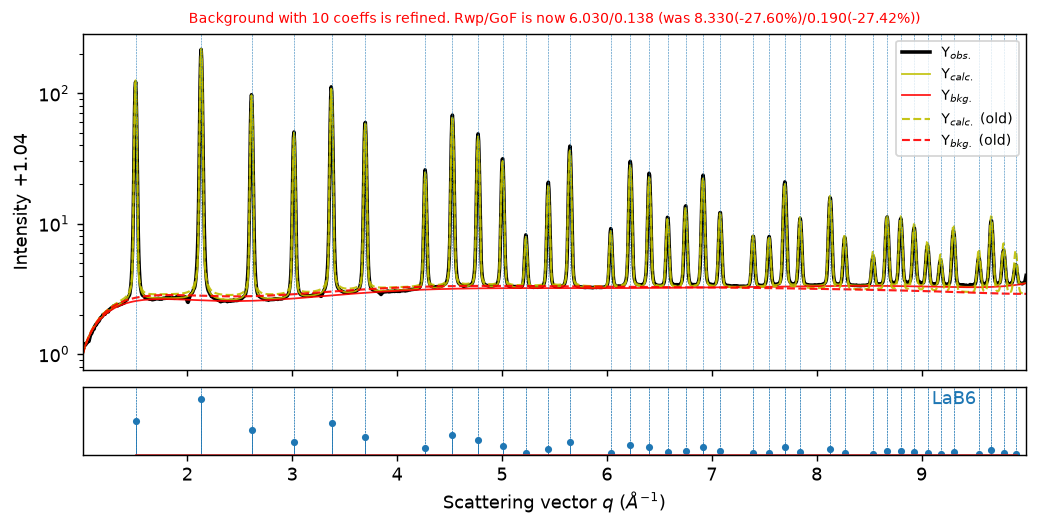

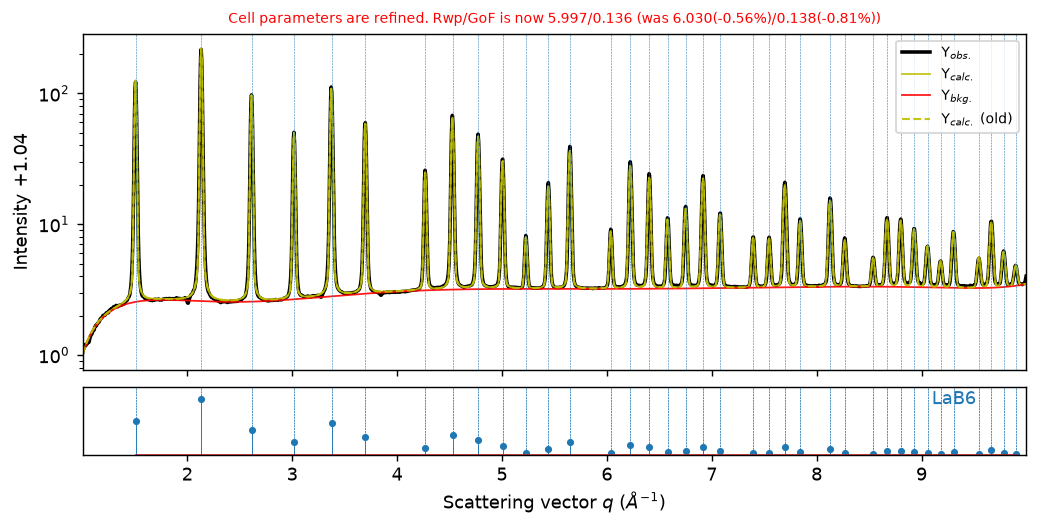

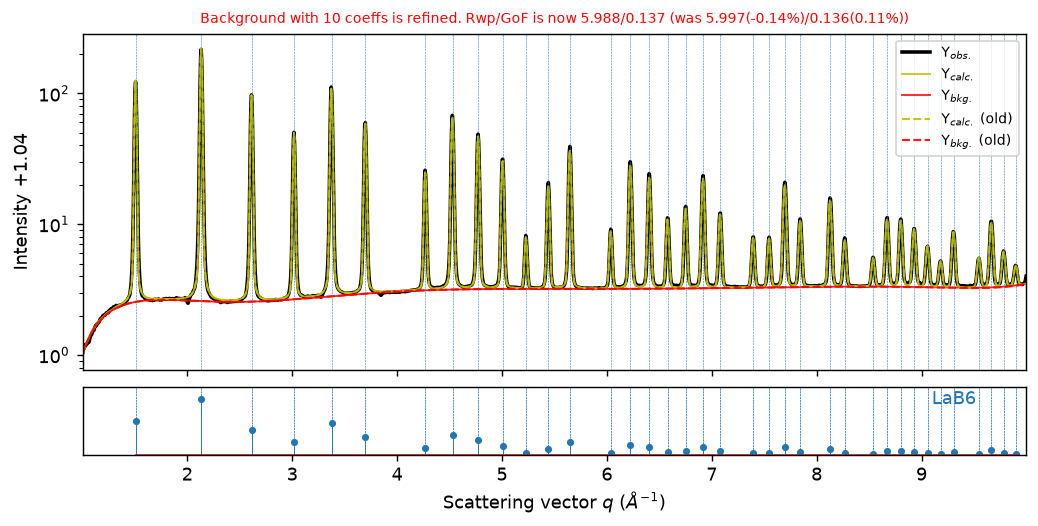

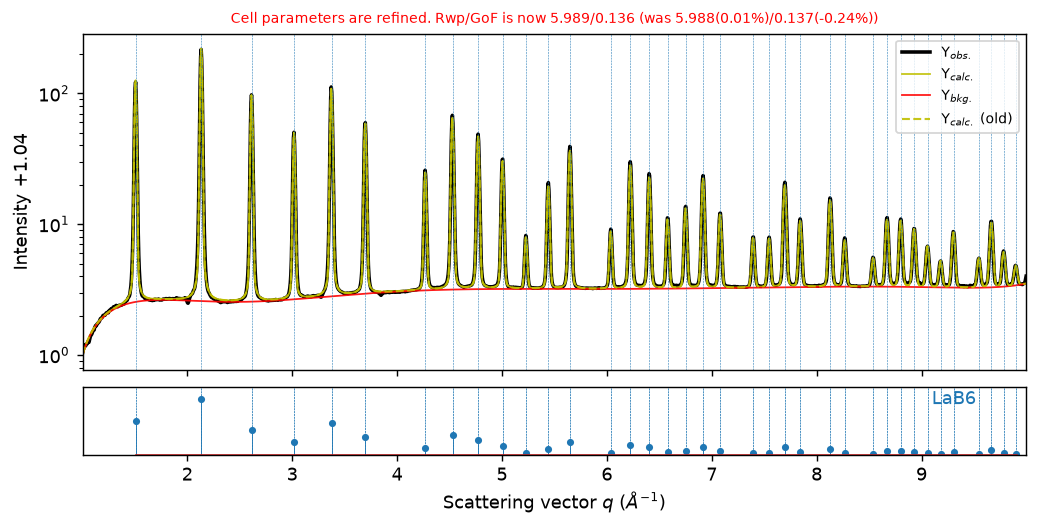

In [18]:
# First pass: refine background and unit cell parameters.
sample.refine_background(plot=True)
sample.refine_cell_parameters(plot=True)

# Second pass: repeat both refinements.
sample.refine_background(plot=True)
sample.refine_cell_parameters(plot=True)


## 9. Switch to Rietveld refinement

Set `LeBail` to `False` and run a refinement. Calculated reflection intensities now depend on the LaB₆ atomic structure. Intensity mismatches that were absorbed by the Le Bail fit can become visible at this stage.


 ✅--After setting LeBail refinement to False, Rwp/GoF is now 10.325/0.235 (was 5.989(72.40%)/0.136(72.35%❗))


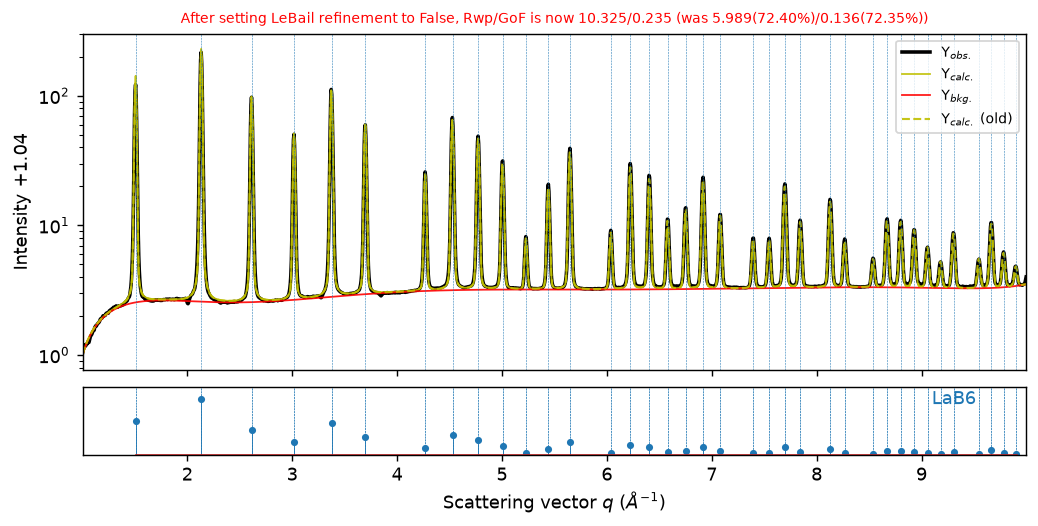

In [19]:
# Switch from Le Bail fitting to structural Rietveld refinement.
sample.set_LeBail(to=False, refine=True, plot=True)


## 10. Refine atomic displacement parameters

Refine the isotropic atomic displacement parameter **Uiso** (Å²) for each site separately. These parameters affect the scattering contribution of each atom, particularly at higher q. The `"U"` refinement flag selects atomic displacement parameters.

### La site

Use `phase_ind=0` for the LaB₆ phase and `site_ind=0` for La in the structure used here. Check the refined value and the resulting intensity agreement.

 ✅--U property of La0 site of LaB6 phase is refined. Rwp/GoF is now 6.357/0.145 (was 10.325(-38.43%)/0.235(-38.41%✨))


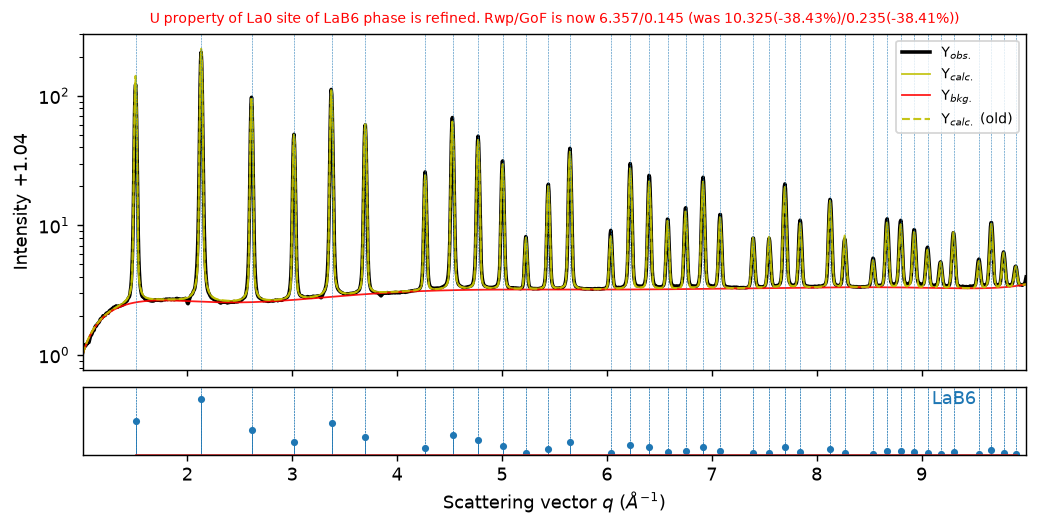

In [20]:
# Refine Uiso for the La site in the LaB6 phase (mp-2680).
sample.refine_site_property(
    phase_ind=0,
    site_ind=0,
    refinement_flags="U",
    plot=True,
)


### B site

Refine Uiso for boron using `site_ind=1` in the same LaB₆ phase. LaB₆ contains La and B; there is no oxygen site in this model.

 ✅--U property of B1 site of LaB6 phase is refined. Rwp/GoF is now 6.173/0.140 (was 6.357(-2.91%)/0.145(-2.91%))


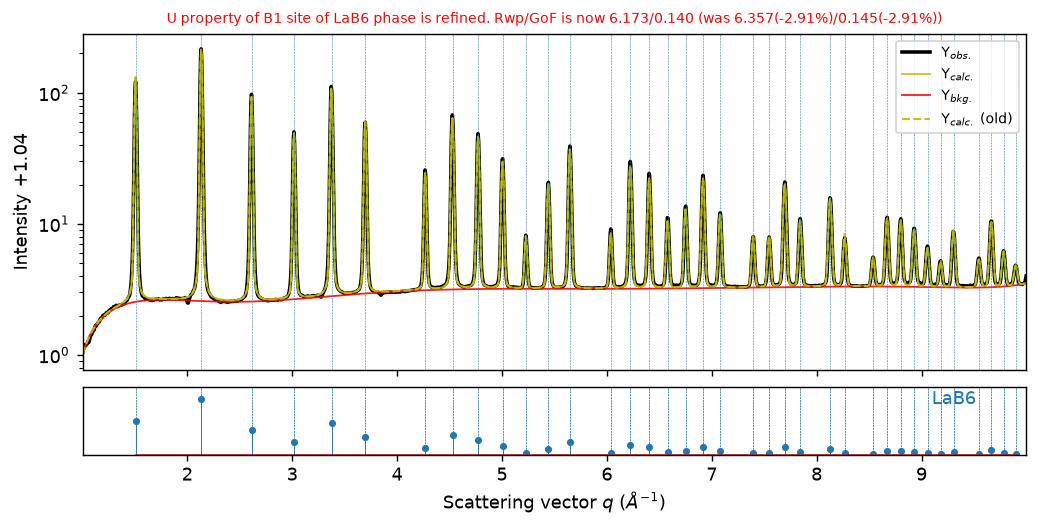

In [21]:
# Refine Uiso for the B site in the LaB6 phase (mp-2680).
sample.refine_site_property(
    phase_ind=0,
    site_ind=1,
    refinement_flags="U",
    plot=True,
)


## 11. Inspect the final refinement plot

Display the current Rietveld fit after the La and B Uiso refinements. Examine peak positions, intensities, widths, and the difference curve together with the reported fit statistics. This cell displays the result without performing an additional refinement.

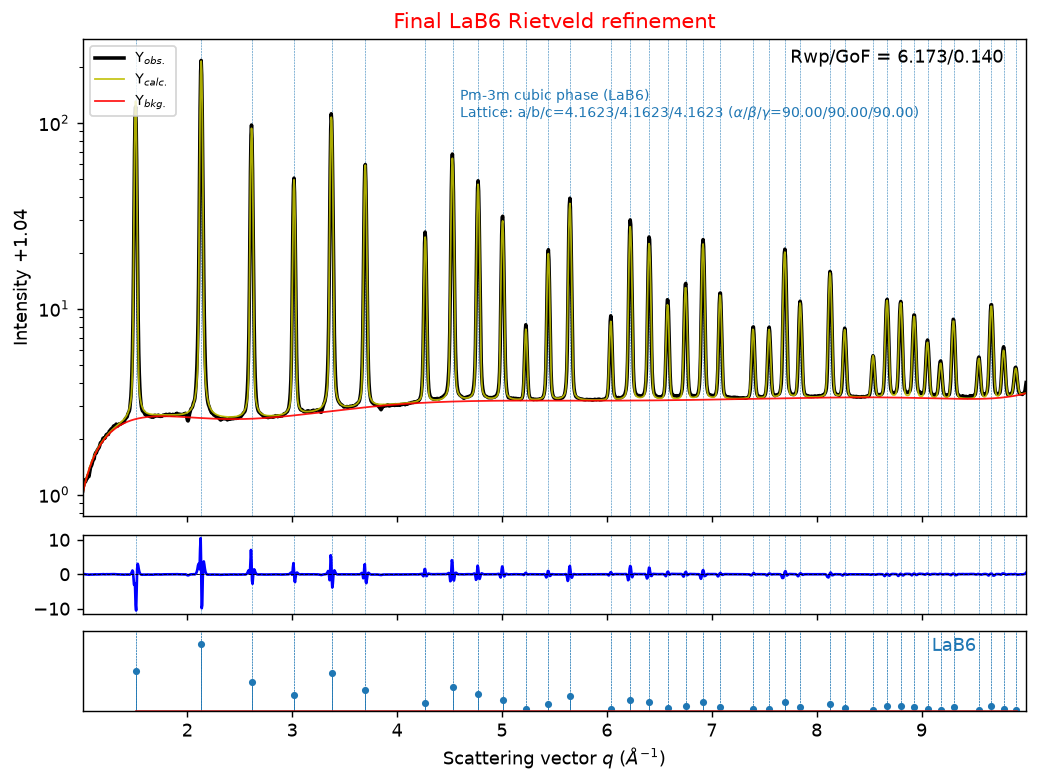

In [22]:
# Display the final LaB6 Rietveld refinement plot.
sample.plot(title="Final LaB6 Rietveld refinement")


## 12. Export the GSAS-II project

After running the preceding refinement cells, export the current `sample` project to `LaB6_refined.gpx` in the working directory. Open this file in GSAS-II to inspect or continue the refinement. Rerunning the export updates the output file with the current project state.

In [23]:
# Export the current refined project for use in GSAS-II.
output_gpx = Path("LaB6_refined.gpx")
sample.export_gpx_to(str(output_gpx))
print(f"Exported GSAS-II project: {output_gpx.resolve()}")


Exported GSAS-II project: /home/mt/temp/GPT-6-Astra-High/LaB6_refined.gpx
